In [2]:
import os
print(os.getcwd())
print(os.listdir())

f:\Workspace\PYTHON\Projects\FeedbackAnalysis\notebooks
['acronyms_dictionary.txt', 'baseline_model.ipynb', 'kiem_tra_dau_tieng_viet.csv', 'main_PhoBERT_sentiment_Kaggle.ipynb', 'main_PhoBERT_topic_Kaggle.ipynb', 'PhoBERT_Data_Preprocessing.ipynb', 'PhoBERT_Inference.ipynb', 'vncorenlp']


In [3]:
import sys
!uv pip install --python {sys.executable} --upgrade transformers accelerate huggingface_hub

Using Python 3.11.15 environment at: f:\Workspace\PYTHON\Projects\FeedbackAnalysis\.venv
Resolved 37 packages in 443ms
Checked 37 packages in 3ms


In [4]:
import os
import json

path = r"F:\Workspace\PYTHON\Projects\FeedbackAnalysis\models\sentiment_model"
config_path = os.path.join(path, "config.json")

print(f"Kiểm tra file: {config_path}")
print(f"File có tồn tại không? {os.path.exists(config_path)}")

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        data = json.load(f)
        print("Nội dung config.json:")
        print(json.dumps(data, indent=2))
        print(f"\nModel type tìm thấy: {data.get('model_type', 'KHÔNG CÓ model_type')}")

Kiểm tra file: F:\Workspace\PYTHON\Projects\FeedbackAnalysis\models\sentiment_model\config.json
File có tồn tại không? True
Nội dung config.json:
{
  "add_cross_attention": false,
  "architectures": [
    "RobertaForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": 2,
    "1": 0,
    "2": 1
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "0": 1,
    "1": 2,
    "2": 0
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 258,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "tokenizer_class": "PhobertTokenizer",
  "transformers_version": "5.0.0",
  "type_vocab_size": 1,
  "use_cache": f

In [8]:
import os
import torch
from transformers import AutoTokenizer, RobertaForSequenceClassification
import re
from underthesea import text_normalize

# =====================================================================
# 1. HỆ THỐNG TIỀN XỬ LÝ (Áp dụng cho câu nhập vào)
# =====================================================================
# Lùi ra 1 cấp từ thư mục notebooks
base_dir = os.path.dirname(os.getcwd()) 
dict_path = os.path.join(base_dir, "acronyms_dictionary.txt")

def load_acronyms(file_path):
    acronyms_dict = {}
    if os.path.exists(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#'): continue
                if '=' in line:
                    key, value = line.split('=', 1)
                    acronyms_dict[key.strip().lower()] = value.strip().lower()
    return acronyms_dict

ACRONYMS_DICT = load_acronyms(dict_path)

# Hàm làm sạch chuyên biệt
def clean_sentence_for_test(text):
    if not isinstance(text, str) or str(text).strip() == "": return ""
    text = str(text).lower()
    text = text_normalize(text)
    
    if ACRONYMS_DICT:
        for shortcut, full_word in ACRONYMS_DICT.items():
            if re.match(r'^\w+$', shortcut, flags=re.UNICODE):
                text = re.sub(r'\b' + shortcut + r'\b', full_word, text)
            else:
                text = text.replace(shortcut, full_word)
                
    try:
        # Nhớ nạp rdrsegmenter vào RAM trước đó nhé
        sentences = rdrsegmenter.word_segment(text)
        text_segmented = sentences[0] if sentences else text
    except Exception:
        text_segmented = text
        
    return text_segmented

# =====================================================================
# 2. KHỞI TẠO BỘ NÃO KÉP (Nạp Model vào RAM)
# =====================================================================
print("⏳ Đang nạp hệ thống phân tích kép...")

# Tokenizer dùng chung
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

# Đường dẫn an toàn bằng os.path.join (Chỏ vào thư mục con best_phobert_model)
path_sentiment_model = os.path.join(base_dir, "models/sentiment_model")
path_topic_model = os.path.join(base_dir, "models/topic_model")

# Kiểm tra chặn lỗi:
if not os.path.exists(os.path.join(path_sentiment_model, "config.json")):
    raise FileNotFoundError(f"❌ Không tìm thấy config.json tại: {path_sentiment_model}")
if not os.path.exists(os.path.join(path_topic_model, "config.json")):
    raise FileNotFoundError(f"❌ Không tìm thấy config.json tại: {path_topic_model}")

# Nạp Não 1
model_sentiment = RobertaForSequenceClassification.from_pretrained(path_sentiment_model, local_files_only=True)
model_sentiment.eval()

# Nạp Não 2
model_topic = RobertaForSequenceClassification.from_pretrained(path_topic_model, local_files_only=True)
model_topic.eval()

print("✅ Hệ thống đã sẵn sàng 100%!")

# =====================================================================
# 3. HÀM ĐIỀU PHỐI CHÍNH (The Facade)
# =====================================================================
def analyze_feedback(text):
    clean_text = clean_sentence_for_test(text)
    inputs = tokenizer(clean_text, return_tensors="pt", padding=True, truncation=True, max_length=256)
    
    with torch.no_grad():
        output_sentiment = model_sentiment(**inputs)
        pred_sentiment_idx = torch.argmax(output_sentiment.logits, dim=1).item()
        label_sentiment = model_sentiment.config.id2label[pred_sentiment_idx]
        
        output_topic = model_topic(**inputs)
        pred_topic_idx = torch.argmax(output_topic.logits, dim=1).item()
        label_topic = model_topic.config.id2label[pred_topic_idx]
        
    return {
        "Raw": text,
        "Cleaned": clean_text,
        "Topic": label_topic,
        "Sentiment": label_sentiment
    }

⏳ Đang nạp hệ thống phân tích kép...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3579.93it/s]

✅ Hệ thống đã sẵn sàng 100%!


In [19]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score
from tqdm.auto import tqdm
import os

# =====================================================================
# 4. CHẤM ĐIỂM MÔ HÌNH TRÊN TẬP TEST
# =====================================================================

# Sử dụng lại base_dir đã khai báo ở Cell 2
# Trỏ đến: FeedbackAnalysis/data/processed/test_clean_PhoBERT.csv
test_csv_path = os.path.join(base_dir, "data", "processed", "test_clean_PhoBERT.csv")

# Zero Trust: Kiểm tra xem có thấy file chưa trước khi chạy
print(f"🔍 Đang kiểm tra file Test tại: {test_csv_path}")
if not os.path.exists(test_csv_path):
    raise FileNotFoundError("❌ Không tìm thấy file test. Hãy kiểm tra lại tên file hoặc thư mục!")
else:
    print("✅ Đã chốt tọa độ file Test. Sẵn sàng lên thớt!\n")

true_topics, pred_topics = [], []
true_sentiments, pred_sentiments = [], []

def evaluate_model_on_test_set(file_path):
    global true_topics, pred_topics, true_sentiments, pred_sentiments
    print("📥 Đang nạp dữ liệu Test...")
    df_test = pd.read_csv(file_path)
    
    texts = df_test['clean_text_PhoBERT'].tolist()
    true_topics = df_test['topic'].tolist() 
    true_sentiments = df_test['sentiment'].tolist()
    
    pred_topics = []
    pred_sentiments = []
    
    print(f"🚀 Bắt đầu chấm điểm {len(texts)} bài thi...")
    for text in tqdm(texts):
        result = analyze_feedback(text)
        # Ép về int để khớp với true_topics
        pred_topics.append(int(result['Topic'])) 
        pred_sentiments.append(int(result['Sentiment']))
        
    print("\n" + "="*55)
    print("🏆 BÁO CÁO THÀNH TÍCH CHỦ ĐỀ (TOPIC)")
    print("="*55)
    print(classification_report(true_topics, pred_topics))
    print(f"✅ Accuracy: {accuracy_score(true_topics, pred_topics):.4f}")

    print("\n" + "="*55)
    print("🏆 BÁO CÁO THÀNH TÍCH CẢM XÚC (SENTIMENT)")
    print("="*55)
    print(classification_report(true_sentiments, pred_sentiments))
    print(f"✅ Accuracy: {accuracy_score(true_sentiments, pred_sentiments):.4f}")

# Gọi hàm để bắt đầu chạy
evaluate_model_on_test_set(test_csv_path)

🔍 Đang kiểm tra file Test tại: f:\Workspace\PYTHON\Projects\FeedbackAnalysis\data\processed\test_clean_PhoBERT.csv
✅ Đã chốt tọa độ file Test. Sẵn sàng lên thớt!

📥 Đang nạp dữ liệu Test...
🚀 Bắt đầu chấm điểm 3166 bài thi...


100%|██████████| 3166/3166 [11:17<00:00,  4.67it/s]  


🏆 BÁO CÁO THÀNH TÍCH CHỦ ĐỀ (TOPIC)
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2290
           1       0.77      0.80      0.78       572
           2       0.94      0.94      0.94       145
           3       0.62      0.47      0.53       159

    accuracy                           0.89      3166
   macro avg       0.82      0.79      0.80      3166
weighted avg       0.89      0.89      0.89      3166

✅ Accuracy: 0.8936

🏆 BÁO CÁO THÀNH TÍCH CẢM XÚC (SENTIMENT)
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      1409
           1       0.73      0.46      0.56       167
           2       0.95      0.96      0.96      1590

    accuracy                           0.94      3166
   macro avg       0.87      0.80      0.83      3166
weighted avg       0.94      0.94      0.94      3166

✅ Accuracy: 0.9397


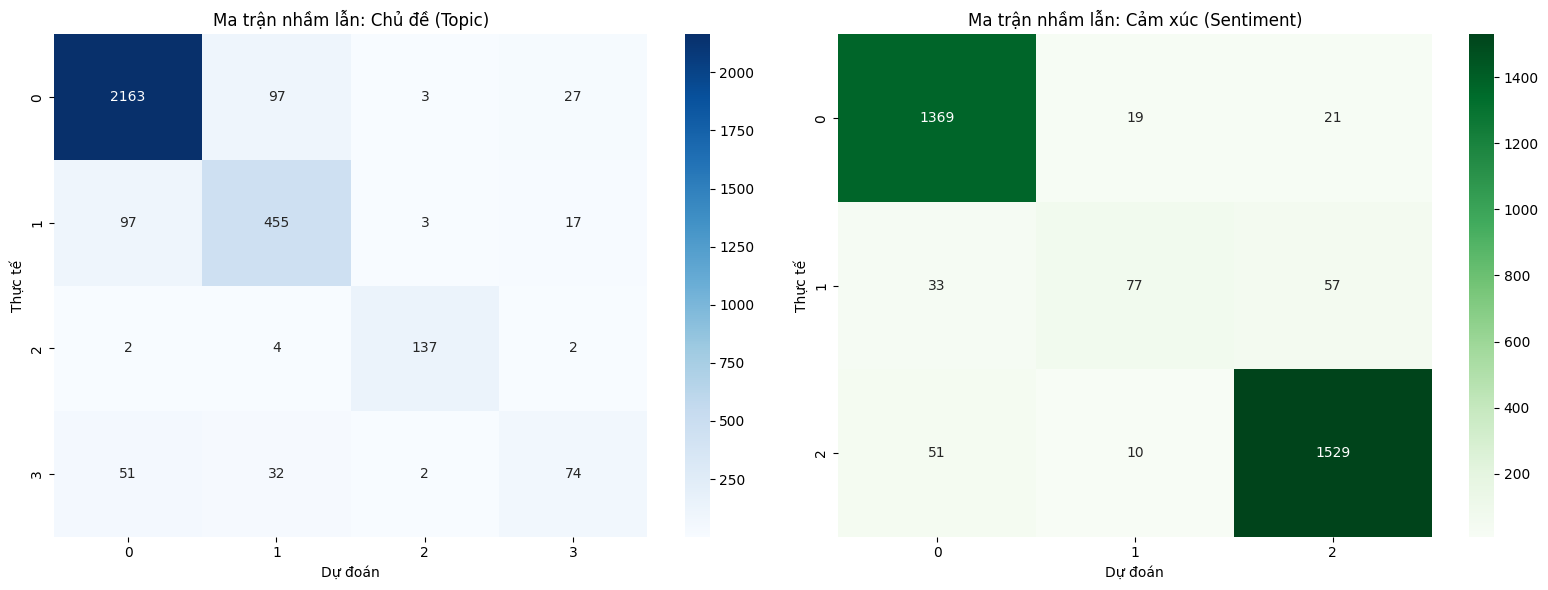

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Chỉ cần chạy Cell này thôi, nó sẽ dùng lại dữ liệu cũ
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Vẽ ma trận cho Topic
sns.heatmap(confusion_matrix(true_topics, pred_topics), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Ma trận nhầm lẫn: Chủ đề (Topic)')
ax[0].set_xlabel('Dự đoán')
ax[0].set_ylabel('Thực tế')

# Vẽ ma trận cho Sentiment
sns.heatmap(confusion_matrix(true_sentiments, pred_sentiments), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Ma trận nhầm lẫn: Cảm xúc (Sentiment)')
ax[1].set_xlabel('Dự đoán')
ax[1].set_ylabel('Thực tế')

plt.tight_layout()
plt.show()

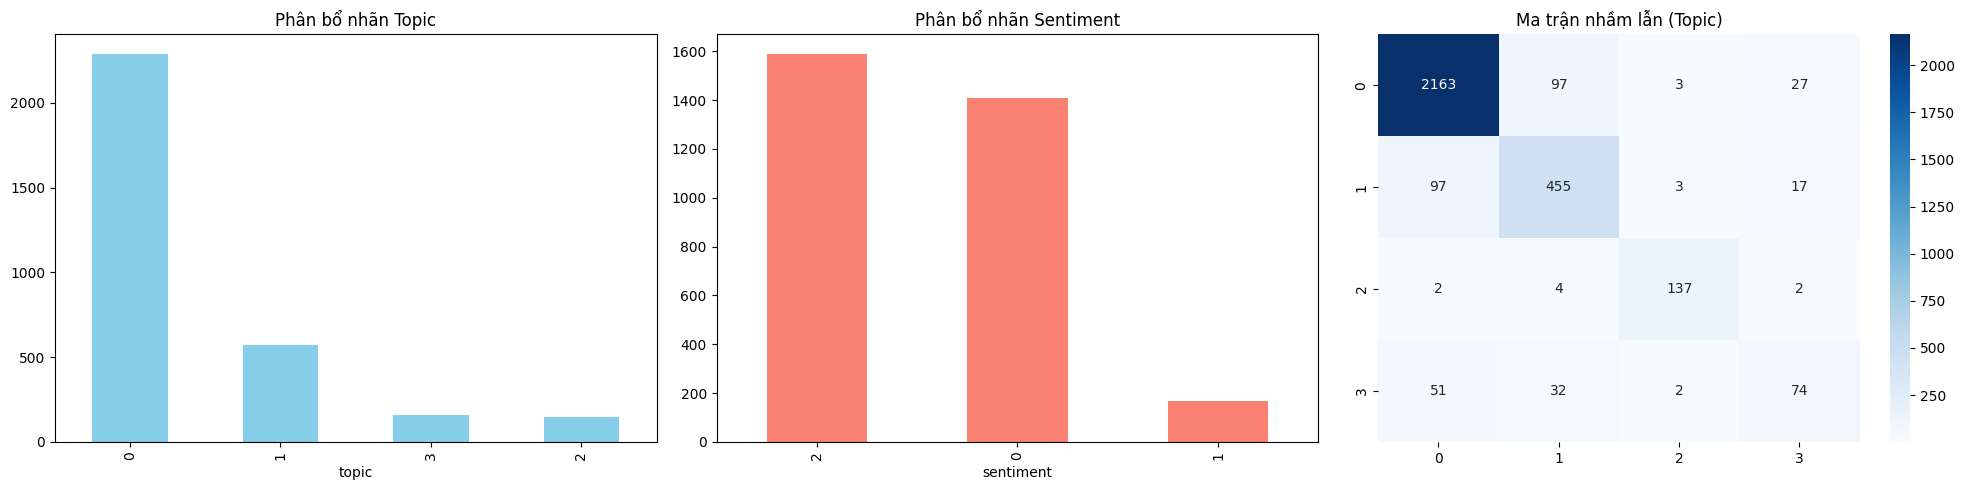

⚠️ Cảnh báo: Chưa tìm thấy thư mục log để vẽ biểu đồ Loss.


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# 1. BIỂU ĐỒ PHÂN BỔ NHÃN (LABEL DISTRIBUTION)
# Để thầy thấy dữ liệu của bạn có bị lệch (imbalance) không
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Phân bổ Topic và Sentiment trong tập Test
df_test = pd.read_csv(test_csv_path) # Đảm bảo file test vẫn được load
df_test['topic'].value_counts().plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Phân bổ nhãn Topic')

df_test['sentiment'].value_counts().plot(kind='bar', ax=ax[1], color='salmon')
ax[1].set_title('Phân bổ nhãn Sentiment')

# 2. MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# Đã sử dụng biến true_... và pred_... từ cell trên
cm_topic = confusion_matrix(true_topics, pred_topics)
sns.heatmap(cm_topic, annot=True, fmt='d', cmap='Blues', ax=ax[2])
ax[2].set_title('Ma trận nhầm lẫn (Topic)')

plt.tight_layout()
plt.show()

# 3. BIỂU ĐỒ TRAINING LOSS (Nếu bạn lưu lịch sử train)
# Bạn thay đường dẫn 'phobert_checkpoints' bằng thư mục checkpoint của bạn
if os.path.exists("./phobert_checkpoints"):
    # Giả sử bạn lưu log, nếu không có log, bạn có thể bỏ qua phần này
    print("✅ Đã sẵn sàng biểu đồ phân tích. Bạn hãy đưa các hình này vào Word ngay nhé!")
else:
    print("⚠️ Cảnh báo: Chưa tìm thấy thư mục log để vẽ biểu đồ Loss.")